# 군집분석 (K-means / DBSCAN) — 다영

목적: `is_fraud`를 쓰지 않고 거래 행동 특성만으로 자연스러운 거래 유형을 찾고, 사후에 각 유형의 실제 이상거래 비율을 확인. 최종적으로 이 군집 정보를 새 변수로 만들어 확정된 최종 모델(LightGBM + 조합3)에 추가했을 때 미래 데이터 PR-AUC가 실제로 좋아지는지 검증.

## 진행 순서
1. 데이터 로드 & 행동변수 EDA (이번 파트)
2. Baseline — 기존 LightGBM(조합3) 3-Fold 성능 재현 (이번 파트)
3. K-means 실험 (K 탐색 → 군집 특성/fraud rate → feature 추가 비교)
4. DBSCAN 실험 (eps/min_samples 탐색 → noise feature 추가 비교)
5. 최종 비교표 (Baseline vs +K-means vs +DBSCAN)

**지켜야 할 규칙**
- 군집 형성에는 `is_fraud` 사용 금지 (군집 만든 뒤 해석 단계에서만 확인)
- 스케일러·K-means·DBSCAN은 항상 그 Fold의 **Train에서만 fit**, Validation은 transform/predict만
- 변수 선택은 Validation 성능을 보고 나중에 바꾸지 않고, 미리 정한 행동변수로 고정해서 진행

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    average_precision_score, precision_score, recall_score, f1_score, confusion_matrix,
)
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42


## 1. 데이터 로드 & 시간순 정렬

In [2]:
DATA_PATH = '../data/fraud_full_features.csv'

df = pd.read_csv(DATA_PATH)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

print('데이터 크기 :', df.shape)
print('기간 :', df['trans_date_trans_time'].min(), '~', df['trans_date_trans_time'].max())
print('전체 사기 비율 :', f"{df['is_fraud'].mean()*100:.4f}%")


데이터 크기 : (1296675, 31)
기간 : 2019-01-01 00:00:18 ~ 2020-06-21 12:13:37
전체 사기 비율 : 0.5789%


## 2. 행동패턴 변수 선정 & EDA

나겸님이 정리해준 7개 후보(조합3에서 카테고리·나이 등 '거래 자체의 성격'보다 '행동'에 가까운 변수만 추림): `amt`, `trans_hour`, `recent_24h_high_amt_count`, `amt_to_prior_median_ratio`, `rolling_sum_amt_1h`, `amt_zscore_card`, `count_30min`.

K-means는 거리 기반이라 **결측치가 있으면 안 되고**, 극단적인 이상치/왜곡된 분포도 거리 계산을 왜곡시키므로 먼저 확인.

In [3]:
BEHAVIOR_FEATURES = [
    'amt',
    'trans_hour',
    'recent_24h_high_amt_count',
    'amt_to_prior_median_ratio',
    'rolling_sum_amt_1h',
    'amt_zscore_card',
    'count_30min',
]

missing = df[BEHAVIOR_FEATURES].isna().sum()
missing_pct = (missing / len(df) * 100).round(4)
print('=== 결측치 ===')
print(pd.DataFrame({'결측건수': missing, '비율(%)': missing_pct}))

print('\n=== 기초 통계량 ===')
print(df[BEHAVIOR_FEATURES].describe().T)


=== 결측치 ===
                           결측건수   비율(%)
amt                           0  0.0000
trans_hour                    0  0.0000
recent_24h_high_amt_count     0  0.0000
amt_to_prior_median_ratio  1649  0.1272
rolling_sum_amt_1h            0  0.0000
amt_zscore_card               0  0.0000
count_30min                   0  0.0000

=== 기초 통계량 ===
                               count       mean         std          min        25%        50%        75%           max
amt                        1296675.0  70.351035  160.316039     1.000000   9.650000  47.520000  83.140000  28948.900000
trans_hour                 1296675.0  12.804858    6.817824     0.000000   7.000000  14.000000  19.000000     23.000000
recent_24h_high_amt_count  1296675.0   0.048169    0.274152     0.000000   0.000000   0.000000   0.000000      9.000000
amt_to_prior_median_ratio  1295026.0   1.643860    4.558937     0.002176   0.260692   1.003543   1.894498    855.709865
rolling_sum_amt_1h         1296675.0  84.911165  194

=== 왜도(skewness) ===
amt_zscore_card              95.346997
amt_to_prior_median_ratio    53.055004
amt                          42.277874
rolling_sum_amt_1h           30.634048
recent_24h_high_amt_count     9.064776
count_30min                   0.020153
trans_hour                   -0.282825
dtype: float64


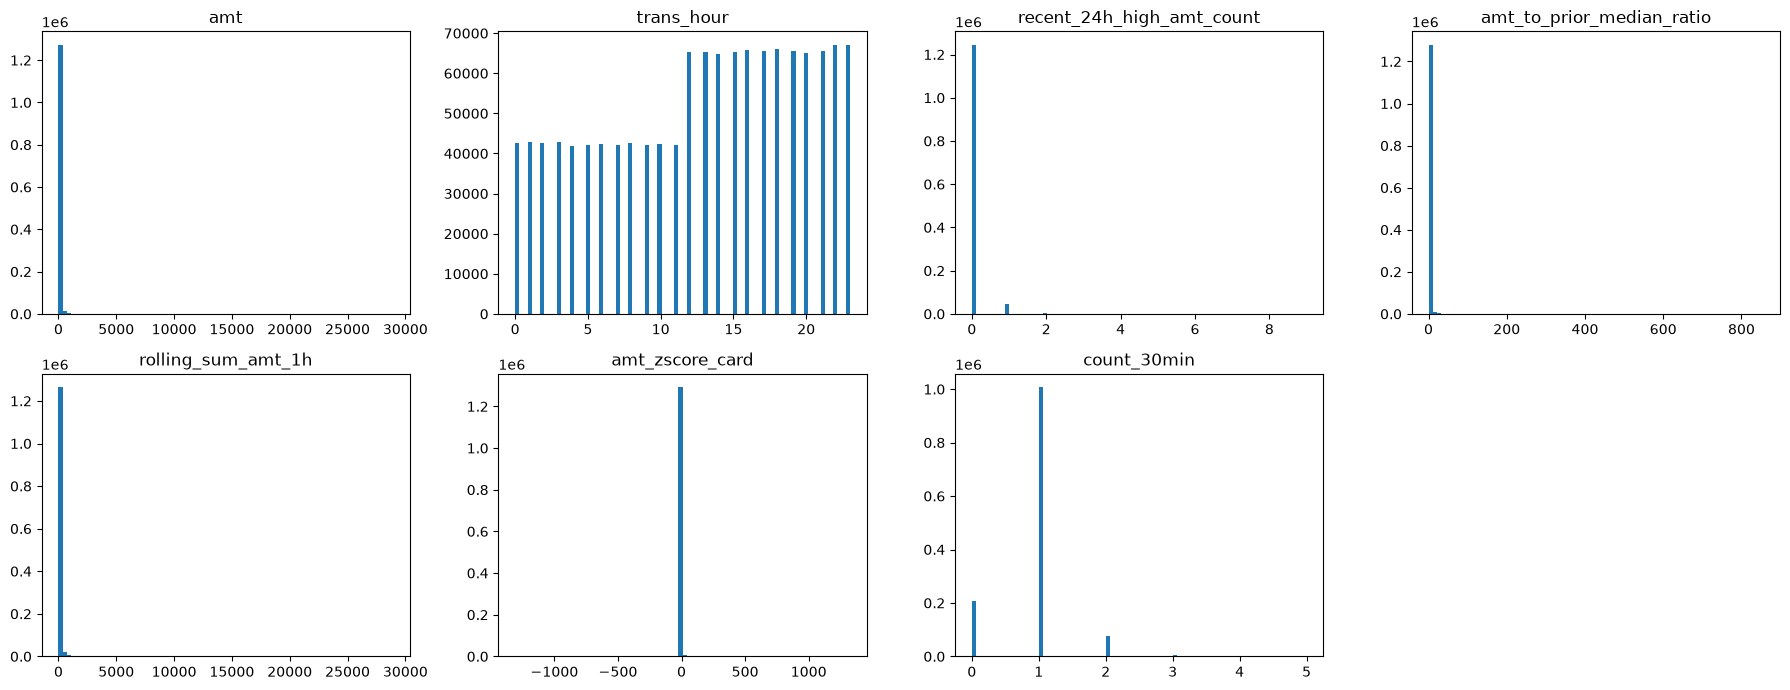

In [4]:
# 왜도(skewness) 확인 — 절대값이 크면(대략 2 이상) 분포가 심하게 치우쳐 K-means 거리계산에 불리
print('=== 왜도(skewness) ===')
print(df[BEHAVIOR_FEATURES].skew().sort_values(ascending=False))

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flatten(), BEHAVIOR_FEATURES):
    ax.hist(df[col].dropna(), bins=80)
    ax.set_title(col)
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()


## 3. Baseline — 기존 LightGBM(조합3) 3-Fold 성능 재현

`final_lightgbm_combination3_config.json`에 저장된 확정 하이퍼파라미터를 그대로 재사용해서, 군집 feature 추가 전/후를 비교할 **기준선(Baseline)**을 다영·민정과 동일한 시간순 3-Fold (행 개수 6등분, 확장형)로 재현.

In [5]:
with open('../Modeling/final_lightgbm_combination3_config.json', encoding='utf-8') as f:
    FINAL_CONFIG = json.load(f)

COMBO3_FEATURES = FINAL_CONFIG['features']
CATEGORICAL_FEATURES = ['category']
HP = FINAL_CONFIG['hyperparameters']
print('조합3 변수 :', COMBO3_FEATURES)
print('\n하이퍼파라미터 :', HP)


조합3 변수 : ['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'high_speed']

하이퍼파라미터 : {'num_leaves': 23, 'max_depth': 5, 'min_child_samples': 150, 'learning_rate': 0.03, 'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'min_split_gain': 0.0, 'max_bin': 255, 'n_estimators': 1756, 'scale_pos_weight': 171.75179856115108, 'random_state': 42}


In [6]:
# 시간순 3-Fold 경계 (다영/민정과 동일한 행 개수 6등분, 확장형)
boundaries = np.linspace(0, len(df), 7, dtype=int)
time_folds = []
for fold_number in range(1, 4):
    train_end = boundaries[fold_number + 2]
    val_start = train_end
    val_end = boundaries[fold_number + 3]
    fold_train = df.iloc[0:train_end].copy()
    fold_val = df.iloc[val_start:val_end].copy()
    time_folds.append({'fold': fold_number, 'train': fold_train, 'val': fold_val})
    print(f"Fold {fold_number} | Train {len(fold_train):,}건(사기 {int(fold_train['is_fraud'].sum())}) "
          f"| Val {len(fold_val):,}건(사기 {int(fold_val['is_fraud'].sum())})")


Fold 1 | Train 648,337건(사기 3827) | Val 216,113건(사기 1091)
Fold 2 | Train 864,450건(사기 4918) | Val 216,112건(사기 1363)
Fold 3 | Train 1,080,562건(사기 6281) | Val 216,113건(사기 1225)


In [7]:
def prepare_lgbm_fold(train_fold, val_fold, features):
    X_train = train_fold[features].copy().reset_index(drop=True)
    X_val = val_fold[features].copy().reset_index(drop=True)
    y_train = train_fold['is_fraud'].astype(np.int8).reset_index(drop=True)
    y_val = val_fold['is_fraud'].astype(np.int8).reset_index(drop=True)

    if 'category' in features:
        train_cats = X_train['category'].astype('string').fillna('missing').unique().tolist()
        X_train['category'] = pd.Categorical(X_train['category'].astype('string').fillna('missing'), categories=train_cats)
        X_val['category'] = pd.Categorical(X_val['category'].astype('string').fillna('missing'), categories=train_cats)

    return X_train, X_val, y_train, y_val


def run_lgbm_cv(features, label, extra_cat_features=None):
    """features: 조합3(+추가 feature) 리스트. extra_cat_features: 범주형으로 취급할 추가 변수(없으면 None)."""
    cat_features = list(CATEGORICAL_FEATURES) + (extra_cat_features or [])
    oof_true, oof_proba = [], []
    fold_pr_aucs = []

    for tf in time_folds:
        X_train, X_val, y_train, y_val = prepare_lgbm_fold(tf['train'], tf['val'], features)

        for c in (extra_cat_features or []):
            train_cats = X_train[c].astype('string').fillna('missing').unique().tolist()
            X_train[c] = pd.Categorical(X_train[c].astype('string').fillna('missing'), categories=train_cats)
            X_val[c] = pd.Categorical(X_val[c].astype('string').fillna('missing'), categories=train_cats)

        spw = (y_train == 0).sum() / (y_train == 1).sum()

        model = LGBMClassifier(
            objective='binary', n_estimators=3000, learning_rate=HP['learning_rate'],
            num_leaves=HP['num_leaves'], max_depth=HP['max_depth'], min_child_samples=HP['min_child_samples'],
            subsample=HP['subsample'], subsample_freq=HP['subsample_freq'], colsample_bytree=HP['colsample_bytree'],
            reg_alpha=HP['reg_alpha'], reg_lambda=HP['reg_lambda'], min_split_gain=HP['min_split_gain'],
            max_bin=HP['max_bin'], scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
        )
        model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='average_precision',
            categorical_feature=cat_features,
            callbacks=[early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False), log_evaluation(period=0)],
        )
        proba_val = model.predict_proba(X_val, num_iteration=model.best_iteration_)[:, 1]
        fold_pr_auc = average_precision_score(y_val, proba_val)
        fold_pr_aucs.append(fold_pr_auc)
        print(f"[{label}] Fold {tf['fold']} | best_iter={model.best_iteration_} | PR-AUC={fold_pr_auc:.6f}")

        oof_true.extend(y_val.to_numpy())
        oof_proba.extend(proba_val)

    oof_true = np.array(oof_true)
    oof_proba = np.array(oof_proba)
    oof_pr_auc = average_precision_score(oof_true, oof_proba)

    print(f"[{label}] 평균 Fold PR-AUC = {np.mean(fold_pr_aucs):.6f} (표준편차 {np.std(fold_pr_aucs):.6f})")
    print(f"[{label}] OOF 통합 PR-AUC  = {oof_pr_auc:.6f}\n")

    return {'label': label, 'fold_pr_aucs': fold_pr_aucs, 'oof_pr_auc': oof_pr_auc,
            'oof_true': oof_true, 'oof_proba': oof_proba}


In [8]:
baseline_result = run_lgbm_cv(COMBO3_FEATURES, 'Baseline(조합3)')

print('참고 — config.json에 저장된 최종 확정 OOF 성능(전체 재학습 기준):')
print(FINAL_CONFIG['oof_results'])


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline(조합3)] Fold 1 | best_iter=2214 | PR-AUC=0.974564


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline(조합3)] Fold 2 | best_iter=1286 | PR-AUC=0.980634


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline(조합3)] Fold 3 | best_iter=1756 | PR-AUC=0.977638
[Baseline(조합3)] 평균 Fold PR-AUC = 0.977612 (표준편차 0.002478)
[Baseline(조합3)] OOF 통합 PR-AUC  = 0.976837

참고 — config.json에 저장된 최종 확정 OOF 성능(전체 재학습 기준):
{'pr_auc': 0.9768374095809191, 'precision': 0.9552155771905424, 'recall': 0.9334058167980429, 'f1_score': 0.9441847676656585, 'fp': 161, 'fn': 245}


## 4. 로그변환 + 스케일링 준비

왜도가 심한 변수(`amt`, `amt_to_prior_median_ratio`, `rolling_sum_amt_1h`, `recent_24h_high_amt_count`)는 `log1p`로 눌러줌(전부 0 이상 값이라 안전). `amt_zscore_card`는 **음수가 나올 수 있는 값**이라 그냥 `log1p`를 쓸 수 없어서, 부호를 유지하면서 크기만 눌러주는 `sign(x) * log1p(|x|)`를 씀. `trans_hour`, `count_30min`은 왜도가 낮아서 그대로 둠.

그리고 결측치(1,649건, `amt_to_prior_median_ratio`)는 **그 Fold의 Train 중앙값**으로 채움 — Validation에도 Train에서 계산한 값을 그대로 적용(중앙값 계산도 leakage 방지 대상).

In [9]:
LOG_POSITIVE_COLS = ['amt', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'recent_24h_high_amt_count']
LOG_SIGNED_COLS = ['amt_zscore_card']


def prepare_cluster_features(train_fold, val_fold, feature_cols=BEHAVIOR_FEATURES):
    """Fold의 Train으로만 결측치 대체값/스케일러를 학습하고, Train/Val 둘 다 변환해서 반환.
    반환: X_train_scaled(ndarray), X_val_scaled(ndarray), scaler, fill_values(dict)
    """
    X_train = train_fold[feature_cols].copy()
    X_val = val_fold[feature_cols].copy()

    # 1) 결측치 대체 (Train 중앙값 기준)
    fill_values = X_train.median(numeric_only=True).to_dict()
    X_train = X_train.fillna(fill_values)
    X_val = X_val.fillna(fill_values)

    # 2) 로그변환
    for c in LOG_POSITIVE_COLS:
        if c in feature_cols:
            X_train[c] = np.log1p(X_train[c].clip(lower=0))
            X_val[c] = np.log1p(X_val[c].clip(lower=0))
    for c in LOG_SIGNED_COLS:
        if c in feature_cols:
            X_train[c] = np.sign(X_train[c]) * np.log1p(X_train[c].abs())
            X_val[c] = np.sign(X_val[c]) * np.log1p(X_val[c].abs())

    # 3) 스케일링 (Train에만 fit)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    return X_train_scaled, X_val_scaled, scaler, fill_values


In [10]:
# 예시로 Fold1에 적용해서 로그변환 전/후 왜도 비교
example_train, example_val, _, _ = prepare_cluster_features(time_folds[0]['train'], time_folds[0]['val'])
example_df = pd.DataFrame(example_train, columns=BEHAVIOR_FEATURES)

print('=== 변환 후 왜도 (Fold1 Train 기준) ===')
print(example_df.skew().sort_values(ascending=False))
print('\n(변환 전 왜도였던 amt_zscore_card=95.3, amt_to_prior_median_ratio=53.1 등과 비교해보기)')


=== 변환 후 왜도 (Fold1 Train 기준) ===
recent_24h_high_amt_count    5.837148
amt_zscore_card              2.042041
amt_to_prior_median_ratio    1.270010
count_30min                 -0.066775
trans_hour                  -0.282530
amt                         -0.296150
rolling_sum_amt_1h          -0.334512
dtype: float64

(변환 전 왜도였던 amt_zscore_card=95.3, amt_to_prior_median_ratio=53.1 등과 비교해보기)


## 5. K값 탐색 (Elbow + Silhouette)

K-means를 쓰려면 K(군집 개수)를 미리 정해야 함. K=2~10까지 다 시도해보면서:
- **Inertia(관성)**: 각 점이 자기 군집 중심에서 얼마나 떨어져 있는지 합친 값 — K가 커질수록 무조건 줄어듦(당연히 잘게 쪼갤수록 가까워지니까), 그래서 절대값이 아니라 **꺾이는 지점(Elbow)**을 봄
- **Silhouette Score**: 내 군집 안 다른 점들과는 가깝고, 다른 군집과는 먼가 — -1~1 사이, 높을수록 좋음

탐색은 Fold3의 Train(가장 크고 최신 정보까지 포함, 2019.01~2020.03)에서 10만 건 샘플로 진행 — 탐색 자체는 '몇 개로 나뉘는 구조인지 보는' 진단 단계라 매 Fold 반복할 필요는 없음. K를 확정한 뒤 실제 성능비교(3-Fold)에서는 각 Fold Train에서 다시 fit함.

K= 2 | Inertia=     471,045 | Silhouette=0.3207 | Davies-Bouldin=1.2028 | Calinski-Harabasz=   48,605 | 군집크기=[np.int64(55485), np.int64(44515)] (최대/최소=1.2배) | 군집별amt평균 폭=102원
K= 3 | Inertia=     389,039 | Silhouette=0.3455 | Davies-Bouldin=1.0408 | Calinski-Harabasz=   39,964 | 군집크기=[np.int64(4031), np.int64(53612), np.int64(42357)] (최대/최소=13.3배) | 군집별amt평균 폭=113원
K= 4 | Inertia=     320,976 | Silhouette=0.2960 | Davies-Bouldin=1.1204 | Calinski-Harabasz=   39,360 | 군집크기=[np.int64(32571), np.int64(15325), np.int64(3925), np.int64(48179)] (최대/최소=12.3배) | 군집별amt평균 폭=217원
K= 5 | Inertia=     272,055 | Silhouette=0.2939 | Davies-Bouldin=1.0807 | Calinski-Harabasz=   39,323 | 군집크기=[np.int64(12017), np.int64(28601), np.int64(30505), np.int64(3915), np.int64(24962)] (최대/최소=7.8배) | 군집별amt평균 폭=248원
K= 6 | Inertia=     241,686 | Silhouette=0.3046 | Davies-Bouldin=1.0793 | Calinski-Harabasz=   37,924 | 군집크기=[np.int64(23841), np.int64(23882), np.int64(28627), np.int64(10269), np.int64(9472), np.in

C:\Users\user\AppData\Local\Temp\ipykernel_7772\2286925691.py:53: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7772\2286925691.py:53: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7772\2286925691.py:53: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7772\2286925691.py:53: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7772\2286925691.py:53: UserWarning: Glyph 52504 (\N{HANGUL SYLLABLE COM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_7772\2286925691.py:53: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) Dej

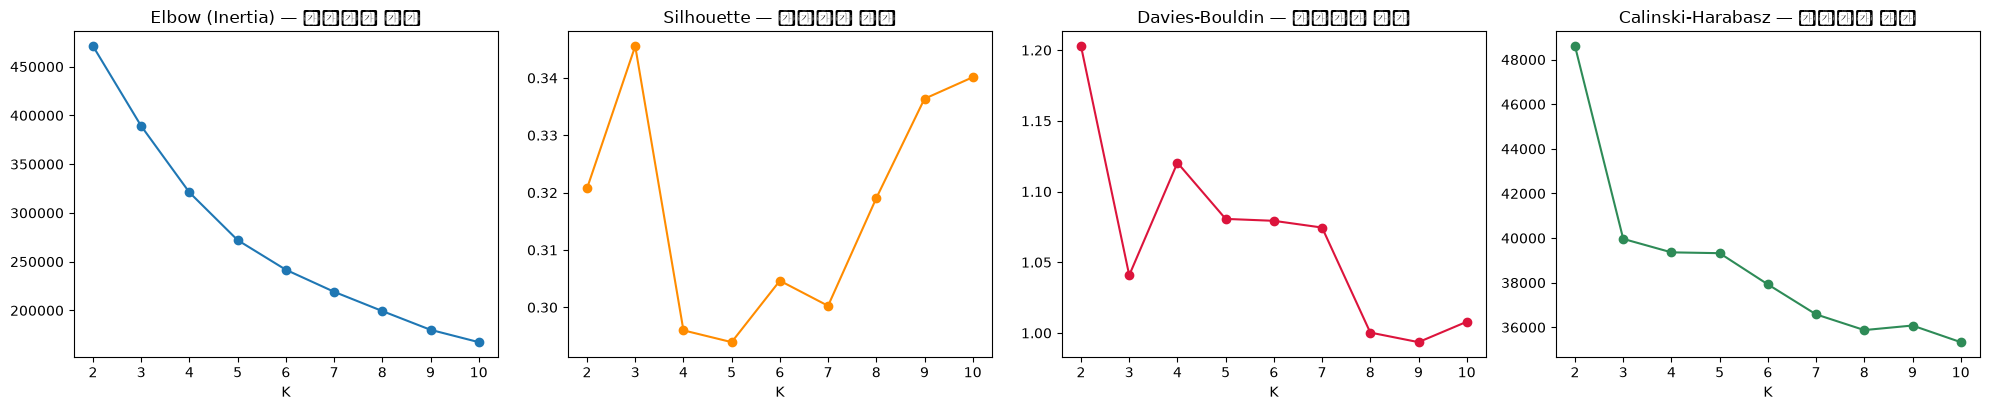

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

SAMPLE_SIZE = 100_000
explore_train = time_folds[2]['train'].sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
explore_val_dummy = time_folds[2]['train'].iloc[:1]  # prepare_cluster_features 형식 맞추기용(사용 안 함)

X_explore, _, _, _ = prepare_cluster_features(explore_train, explore_val_dummy)
explore_amt = explore_train['amt'].to_numpy()  # 군집별 실제 특성(대표로 amt) 확인용

k_candidates = range(2, 11)
k_search_rows = []

for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_explore)

    sil = silhouette_score(X_explore, labels, sample_size=20000, random_state=RANDOM_STATE)
    db_score = davies_bouldin_score(X_explore, labels)          # 낮을수록 좋음
    ch_score = calinski_harabasz_score(X_explore, labels)       # 높을수록 좋음

    sizes = np.bincount(labels)
    size_ratio = sizes.max() / sizes.min()  # 제일 큰 군집이 제일 작은 군집의 몇 배인지 (너무 크면 '한쪽으로 쏠린' 군집)
    amt_means = [explore_amt[labels == c].mean() for c in range(k)]
    amt_range = max(amt_means) - min(amt_means)  # 군집별 실제 금액 특성이 얼마나 다른지

    print(f'K={k:2d} | Inertia={km.inertia_:>12,.0f} | Silhouette={sil:.4f} | '
          f'Davies-Bouldin={db_score:.4f} | Calinski-Harabasz={ch_score:>9,.0f} | '
          f'군집크기={list(sizes)} (최대/최소={size_ratio:.1f}배) | 군집별amt평균 폭={amt_range:,.0f}원')

    k_search_rows.append({
        'K': k, 'inertia': km.inertia_, 'silhouette': sil, 'davies_bouldin': db_score,
        'calinski_harabasz': ch_score, 'min_cluster_size': sizes.min(), 'max_cluster_size': sizes.max(),
        'size_ratio': size_ratio, 'amt_mean_range': amt_range,
    })

k_search_df = pd.DataFrame(k_search_rows)
print()
print(k_search_df.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
axes[0].plot(k_search_df['K'], k_search_df['inertia'], marker='o')
axes[0].set_title('Elbow (Inertia) — 낮을수록 촘촘'); axes[0].set_xlabel('K')

axes[1].plot(k_search_df['K'], k_search_df['silhouette'], marker='o', color='darkorange')
axes[1].set_title('Silhouette — 높을수록 좋음'); axes[1].set_xlabel('K')

axes[2].plot(k_search_df['K'], k_search_df['davies_bouldin'], marker='o', color='crimson')
axes[2].set_title('Davies-Bouldin — 낮을수록 좋음'); axes[2].set_xlabel('K')

axes[3].plot(k_search_df['K'], k_search_df['calinski_harabasz'], marker='o', color='seagreen')
axes[3].set_title('Calinski-Harabasz — 높을수록 좋음'); axes[3].set_xlabel('K')

plt.tight_layout()
plt.show()


## 6. K=3 확정 — Fold별 군집 생성 & 특성/Fraud rate 확인

Silhouette 기준 + 해석 용이성을 고려해 **K=3**으로 확정. 이제부터는 팀 표준 3-Fold 각각에 대해 '그 Fold의 Train에서만 K-means를 학습 → Train/Val 둘 다에 군집번호 부여'를 반복(leakage 방지).

군집이 만들어진 뒤에야 `is_fraud`를 꺼내서 확인 — 이 순서를 반드시 지킴.

In [12]:
K_FINAL = 3

cluster_assignments = []  # Fold별로 (train_cluster, val_cluster) 저장

for tf in time_folds:
    X_train_scaled, X_val_scaled, scaler, fill_values = prepare_cluster_features(tf['train'], tf['val'])

    km = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_train_scaled)  # Train에만 fit

    train_cluster = km.predict(X_train_scaled)
    val_cluster = km.predict(X_val_scaled)  # Val은 predict만 (재학습 없음)

    cluster_assignments.append({
        'fold': tf['fold'], 'kmeans': km,
        'train_cluster': train_cluster, 'val_cluster': val_cluster,
    })

    print(f"Fold {tf['fold']} | Train 군집 분포: {np.bincount(train_cluster)} | "
          f"Val 군집 분포: {np.bincount(val_cluster)}")


Fold 1 | Train 군집 분포: [274868 349188  24281] | Val 군집 분포: [ 89369 116343  10401]
Fold 2 | Train 군집 분포: [366551 463217  34682] | Val 군집 분포: [ 90786 116417   8909]
Fold 3 | Train 군집 분포: [546777 365516 168269] | Val 군집 분포: [111746  72850  31517]


In [13]:
# 군집별 특성 확인 — Fold3(가장 최신까지 포함) 기준으로 대표 확인
example_fold = time_folds[2]
example_assign = cluster_assignments[2]

profile_df = example_fold['train'][BEHAVIOR_FEATURES].copy()
profile_df['cluster'] = example_assign['train_cluster']
profile_df['is_fraud'] = example_fold['train']['is_fraud'].to_numpy()

print('=== 군집별 평균 특성 (Fold3 Train, 원 단위 그대로) ===')
print(profile_df.groupby('cluster')[BEHAVIOR_FEATURES].mean().round(2))

print('\n=== 군집별 크기 & Fraud rate ===')
cluster_fraud = profile_df.groupby('cluster').agg(
    거래건수=('is_fraud', 'size'),
    사기건수=('is_fraud', 'sum'),
    사기비율=('is_fraud', 'mean'),
)
cluster_fraud['사기비율(%)'] = (cluster_fraud['사기비율'] * 100).round(4)
cluster_fraud['전체사기중비중(%)'] = (cluster_fraud['사기건수'] / cluster_fraud['사기건수'].sum() * 100).round(2)
print(cluster_fraud[['거래건수', '사기건수', '사기비율(%)', '전체사기중비중(%)']])

overall_rate = profile_df['is_fraud'].mean() * 100
print(f"\n전체 평균 사기비율: {overall_rate:.4f}% (비교 기준)")


=== 군집별 평균 특성 (Fold3 Train, 원 단위 그대로) ===
            amt  trans_hour  recent_24h_high_amt_count  amt_to_prior_median_ratio  rolling_sum_amt_1h  amt_zscore_card  count_30min
cluster                                                                                                                            
0         61.50       12.04                       0.04                       1.37               78.11            -0.09         0.97
1          8.22       14.40                       0.04                       0.21               13.94            -0.53         0.81
2        233.95       11.80                       0.09                       5.70              261.99             1.66         0.93

=== 군집별 크기 & Fraud rate ===
           거래건수  사기건수  사기비율(%)  전체사기중비중(%)
cluster                                   
0        546777   784   0.1434       12.48
1        365516   788   0.2156       12.55
2        168269  4709   2.7985       74.97

전체 평균 사기비율: 0.5813% (비교 기준)


### 군집 x Fraud 통계적 검정 (카이제곱 독립성 검정)

"군집 소속"과 "사기 여부"가 우연히 관련 없어 보이는데 그런 건 아닌지, 통계적으로 확인.

In [14]:
from scipy.stats import chi2_contingency

contingency_kmeans = pd.crosstab(profile_df['cluster'], profile_df['is_fraud'])
chi2, p_value, dof, expected = chi2_contingency(contingency_kmeans)

print('=== K-means 군집 x Fraud 카이제곱 독립성 검정 (Fold3 Train 기준) ===')
print(contingency_kmeans)
print(f'chi2 = {chi2:.2f}, p-value = {p_value:.2e}, 자유도 = {dof}')
if p_value < 0.05:
    print('-> p < 0.05: 군집과 사기 여부가 통계적으로 유의하게 관련 있음 (독립이라는 귀무가설 기각)')
else:
    print('-> p >= 0.05: 통계적으로 유의한 관련을 찾지 못함')


=== K-means 군집 x Fraud 카이제곱 독립성 검정 (Fold3 Train 기준) ===
is_fraud       0     1
cluster               
0         545993   784
1         364728   788
2         163560  4709
chi2 = 16974.50, p-value = 0.00e+00, 자유도 = 2
-> p < 0.05: 군집과 사기 여부가 통계적으로 유의하게 관련 있음 (독립이라는 귀무가설 기각)


## 7. K-means 군집 feature를 기존 LightGBM(조합3)에 추가 — 성능 비교

각 Fold에서 만든 군집번호(0/1/2)를 새로운 범주형 변수로 만들어서 기존 34개(→여기선 조합3 11개) 변수에 추가하고, 똑같은 3-Fold로 다시 학습해서 Baseline과 PR-AUC를 비교.

In [15]:
# 기존 time_folds에 kmeans_cluster 컬럼을 추가한 새 fold 리스트 생성
time_folds_kmeans = []
for tf, assign in zip(time_folds, cluster_assignments):
    train_fold = tf['train'].copy()
    val_fold = tf['val'].copy()
    train_fold['kmeans_cluster'] = assign['train_cluster'].astype(str)
    val_fold['kmeans_cluster'] = assign['val_cluster'].astype(str)
    time_folds_kmeans.append({'fold': tf['fold'], 'train': train_fold, 'val': val_fold})

print('kmeans_cluster 고유값:', sorted(time_folds_kmeans[0]['train']['kmeans_cluster'].unique()))


kmeans_cluster 고유값: ['0', '1', '2']


In [16]:
# run_lgbm_cv가 전역 time_folds를 참조하므로, 이번만 임시로 바꿔서 실행
_original_time_folds = time_folds
time_folds = time_folds_kmeans

kmeans_result = run_lgbm_cv(
    COMBO3_FEATURES + ['kmeans_cluster'], 'Baseline + K-means cluster',
    extra_cat_features=['kmeans_cluster'],
)

time_folds = _original_time_folds  # 원래대로 복구

diff = kmeans_result['oof_pr_auc'] - baseline_result['oof_pr_auc']
print(f"\nBaseline OOF PR-AUC       = {baseline_result['oof_pr_auc']:.6f}")
print(f"+K-means cluster OOF PR-AUC = {kmeans_result['oof_pr_auc']:.6f}")
print(f"차이 = {diff:+.6f}")


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + K-means cluster] Fold 1 | best_iter=2234 | PR-AUC=0.973294


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + K-means cluster] Fold 2 | best_iter=1614 | PR-AUC=0.980692


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + K-means cluster] Fold 3 | best_iter=1689 | PR-AUC=0.977910
[Baseline + K-means cluster] 평균 Fold PR-AUC = 0.977299 (표준편차 0.003051)
[Baseline + K-means cluster] OOF 통합 PR-AUC  = 0.976791


Baseline OOF PR-AUC       = 0.976837
+K-means cluster OOF PR-AUC = 0.976791
차이 = -0.000047


## 8. DBSCAN — 이상치(Noise) 탐색

K-means와 달리 DBSCAN은 **`predict()` 메서드가 없음** — 밀도는 '그 데이터셋 안에서의 상대적 위치'로 정해지는 개념이라, 새로운(Validation) 점에 대해 '몇 번 군집이냐'를 다시 계산할 방법이 원래 없음. 그래서 DBSCAN의 정의(핵심점=core point 반경 eps 안에 min_samples개 이상 이웃이 있는 점)를 그대로 이용해서 직접 predict 함수를 만듦: **Validation의 각 점이 Train의 core point 중 하나와 eps 이내로 가까우면 '군집(정상 패턴)', 하나도 없으면 'Noise(이상치)'**로 판정.

먼저 eps/min_samples를 정하기 위해 k-거리 그래프(k-distance plot)를 그림 — 각 점에서 k번째로 가까운 이웃까지의 거리를 오름차순 정렬했을 때 급격히 꺾이는 지점이 좋은 eps 후보.

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50883 (\N{HANGUL SYLLABLE US}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPyth

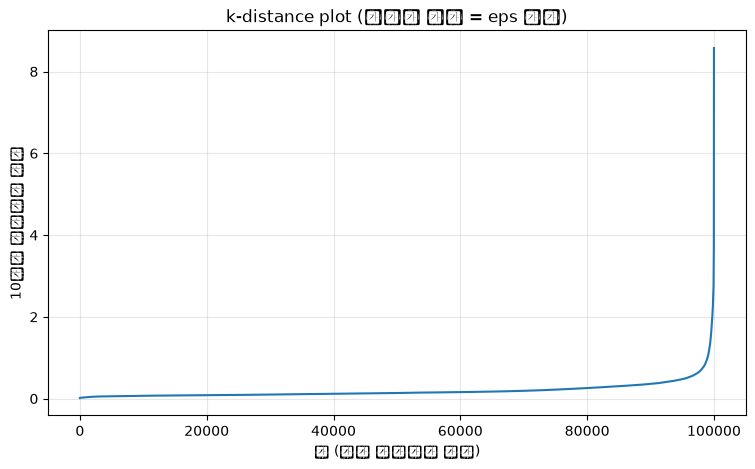

80백분위수 거리 = 0.2579
90백분위수 거리 = 0.3598
95백분위수 거리 = 0.4760
97백분위수 거리 = 0.5899
99백분위수 거리 = 1.0074


In [17]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES_CANDIDATE = 10  # 대략 '변수 개수(7) x 1.5' 근방에서 시작하는 일반적 관행

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES_CANDIDATE)
nn.fit(X_explore)
distances, _ = nn.kneighbors(X_explore)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.xlabel('점 (거리 오름차순 정렬)')
plt.ylabel(f'{MIN_SAMPLES_CANDIDATE}번째 이웃까지 거리')
plt.title('k-distance plot (꺾이는 지점 = eps 후보)')
plt.grid(alpha=0.3)
plt.show()

for p in [80, 90, 95, 97, 99]:
    print(f'{p}백분위수 거리 = {np.percentile(k_distances, p):.4f}')


### eps / min_samples 후보 그리드 — 군집 수·Noise 비율 확인

In [18]:
eps_candidates = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_candidates = [10, 20]

grid_rows = []
for eps in eps_candidates:
    for min_samples in min_samples_candidates:
        db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = db.fit_predict(X_explore)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = (labels == -1).mean() * 100

        row = {'eps': eps, 'min_samples': min_samples, '군집수': n_clusters, 'Noise비율(%)': round(noise_ratio, 2)}

        if n_clusters >= 2 and noise_ratio < 100:
            mask = labels != -1
            if mask.sum() > 1000 and len(set(labels[mask])) >= 2:
                sil = silhouette_score(X_explore[mask], labels[mask], sample_size=min(20000, mask.sum()), random_state=RANDOM_STATE)
                row['Silhouette(noise제외)'] = round(sil, 4)

        grid_rows.append(row)
        print(row)

grid_df = pd.DataFrame(grid_rows)
print()
print(grid_df.to_string(index=False))


{'eps': 0.3, 'min_samples': 10, '군집수': 40, 'Noise비율(%)': np.float64(10.29), 'Silhouette(noise제외)': -0.2646}
{'eps': 0.3, 'min_samples': 20, '군집수': 22, 'Noise비율(%)': np.float64(15.51), 'Silhouette(noise제외)': -0.1348}
{'eps': 0.5, 'min_samples': 10, '군집수': 15, 'Noise비율(%)': np.float64(2.63), 'Silhouette(noise제외)': 0.2117}
{'eps': 0.5, 'min_samples': 20, '군집수': 12, 'Noise비율(%)': np.float64(3.89), 'Silhouette(noise제외)': 0.1565}
{'eps': 0.7, 'min_samples': 10, '군집수': 15, 'Noise비율(%)': np.float64(1.24), 'Silhouette(noise제외)': 0.2043}
{'eps': 0.7, 'min_samples': 20, '군집수': 9, 'Noise비율(%)': np.float64(1.79), 'Silhouette(noise제외)': 0.2225}
{'eps': 1.0, 'min_samples': 10, '군집수': 14, 'Noise비율(%)': np.float64(0.67), 'Silhouette(noise제외)': 0.2248}
{'eps': 1.0, 'min_samples': 20, '군집수': 10, 'Noise비율(%)': np.float64(0.9), 'Silhouette(noise제외)': 0.2298}
{'eps': 1.5, 'min_samples': 10, '군집수': 15, 'Noise비율(%)': np.float64(0.32), 'Silhouette(noise제외)': 0.2313}
{'eps': 1.5, 'min_samples': 20, '군집수': 10, '

## 9. eps=0.5, min_samples=10 확정 — Fold별 Noise 산출

eps가 너무 작으면(0.3) Noise가 10~15%로 너무 많고 군집도 과하게 쪼개짐(실루엣도 음수). 너무 크면(1.5~2.0) Noise가 0.1~0.3%로 거의 없어서 사기율을 안정적으로 비교하기 힘듦. **eps=0.5, min_samples=10**을 채택 — Noise 비율 약 2.6%, 실루엣 0.21로 준수.

Validation 적용 방식: DBSCAN은 `predict()`가 없으므로, **Validation의 각 점을 Train의 core point들과 비교해서 eps 이내에 있는 가장 가까운 core point가 있으면 그 군집으로, 하나도 없으면 Noise로 판정**하는 함수를 직접 구현(DBSCAN 정의를 그대로 적용한 것).

In [19]:
from sklearn.neighbors import NearestNeighbors

EPS_FINAL = 0.5
MIN_SAMPLES_FINAL = 10
DBSCAN_SAMPLE_SIZE = 150_000  # Fold 전체(최대 108만건)에 그대로 fit하면 MemoryError -> 샘플링 필수


def dbscan_fit_and_assign(X_train_scaled, X_val_scaled, eps=EPS_FINAL, min_samples=MIN_SAMPLES_FINAL,
                           sample_size=DBSCAN_SAMPLE_SIZE, random_state=RANDOM_STATE):
    n = len(X_train_scaled)
    if n > sample_size:
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(n, size=sample_size, replace=False)
    else:
        sample_idx = np.arange(n)
    X_sample = X_train_scaled[sample_idx]

    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    sample_labels = db.fit_predict(X_sample)  # DBSCAN 학습은 샘플에만 (leakage와는 무관, 순수 연산량 문제)
    core_samples = X_sample[db.core_sample_indices_]
    core_labels = sample_labels[db.core_sample_indices_]

    if len(core_samples) == 0:
        train_labels = np.full(n, -1)
        val_labels = np.full(len(X_val_scaled), -1)
        train_dist = np.full(n, np.inf)
        val_dist = np.full(len(X_val_scaled), np.inf)
        return train_labels, val_labels, train_dist, val_dist, db

    # Train 전체 & Val 둘 다 '샘플에서 나온 core point와 eps 이내로 가장 가까운가'로 판정
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(core_samples)

    dist_train, idx_train = nn.kneighbors(X_train_scaled)
    train_labels = np.where(dist_train[:, 0] <= eps, core_labels[idx_train[:, 0]], -1)

    dist_val, idx_val = nn.kneighbors(X_val_scaled)
    val_labels = np.where(dist_val[:, 0] <= eps, core_labels[idx_val[:, 0]], -1)

    # dist_to_core: '가장 가까운 core point까지의 거리' 자체를 연속형 파생 피처로도 사용(Noise 여부보다 더 정밀한 정보)
    return train_labels, val_labels, dist_train[:, 0], dist_val[:, 0], db


dbscan_assignments = []
for tf in time_folds:
    X_train_scaled, X_val_scaled, scaler, fill_values = prepare_cluster_features(tf['train'], tf['val'])
    train_labels, val_labels, train_dist, val_dist, db = dbscan_fit_and_assign(X_train_scaled, X_val_scaled)

    dbscan_assignments.append({
        'fold': tf['fold'], 'train_labels': train_labels, 'val_labels': val_labels,
        'train_dist': train_dist, 'val_dist': val_dist,
    })

    train_noise_pct = (train_labels == -1).mean() * 100
    val_noise_pct = (val_labels == -1).mean() * 100
    print(f"Fold {tf['fold']} | Train Noise {train_noise_pct:.2f}% ({(train_labels==-1).sum():,}건) | "
          f"Val Noise {val_noise_pct:.2f}% ({(val_labels==-1).sum():,}건)")


Fold 1 | Train Noise 2.30% (14,881건) | Val Noise 2.39% (5,170건)
Fold 2 | Train Noise 2.27% (19,637건) | Val Noise 1.97% (4,247건)
Fold 3 | Train Noise 2.19% (23,655건) | Val Noise 1.62% (3,497건)


In [20]:
# Noise 특성 & Fraud rate 확인 (Fold3 Train 기준)
example_fold = time_folds[2]
example_labels = dbscan_assignments[2]['train_labels']

noise_profile = example_fold['train'][BEHAVIOR_FEATURES].copy()
noise_profile['is_noise'] = (example_labels == -1).astype(int)
noise_profile['is_fraud'] = example_fold['train']['is_fraud'].to_numpy()

print('=== Noise 여부별 평균 특성 (Fold3 Train) ===')
print(noise_profile.groupby('is_noise')[BEHAVIOR_FEATURES].mean().round(2))

print('\n=== Noise 여부별 크기 & Fraud rate ===')
noise_fraud = noise_profile.groupby('is_noise').agg(
    거래건수=('is_fraud', 'size'), 사기건수=('is_fraud', 'sum'), 사기비율=('is_fraud', 'mean'),
)
noise_fraud['사기비율(%)'] = (noise_fraud['사기비율'] * 100).round(4)
noise_fraud['전체사기중비중(%)'] = (noise_fraud['사기건수'] / noise_fraud['사기건수'].sum() * 100).round(2)
print(noise_fraud[['거래건수', '사기건수', '사기비율(%)', '전체사기중비중(%)']])
print(f"\n전체 평균 사기비율: {example_fold['train']['is_fraud'].mean()*100:.4f}%")


=== Noise 여부별 평균 특성 (Fold3 Train) ===
             amt  trans_hour  recent_24h_high_amt_count  amt_to_prior_median_ratio  rolling_sum_amt_1h  amt_zscore_card  count_30min
is_noise                                                                                                                            
0          62.56       12.78                       0.03                       1.43               72.42            -0.05         0.91
1         417.56       13.68                       0.90                      11.92              648.84             3.58         1.11

=== Noise 여부별 크기 & Fraud rate ===
             거래건수  사기건수  사기비율(%)  전체사기중비중(%)
is_noise                                    
0         1056907  1616   0.1529       25.73
1           23655  4665  19.7210       74.27

전체 평균 사기비율: 0.5813%


### Noise x Fraud 통계적 검정 (카이제곱 독립성 검정)

"Noise 여부"와 "사기 여부"가 우연히 관련 없어 보이는데 그런 건 아닌지, 통계적으로 확인.

In [21]:
from scipy.stats import chi2_contingency

contingency_dbscan = pd.crosstab(noise_profile['is_noise'], noise_profile['is_fraud'])
chi2, p_value, dof, expected = chi2_contingency(contingency_dbscan)

print('=== DBSCAN Noise x Fraud 카이제곱 독립성 검정 (Fold3 Train 기준) ===')
print(contingency_dbscan)
print(f'chi2 = {chi2:.2f}, p-value = {p_value:.2e}, 자유도 = {dof}')
if p_value < 0.05:
    print('-> p < 0.05: Noise 여부와 사기 여부가 통계적으로 유의하게 관련 있음 (독립이라는 귀무가설 기각)')
else:
    print('-> p >= 0.05: 통계적으로 유의한 관련을 찾지 못함')


=== DBSCAN Noise x Fraud 카이제곱 독립성 검정 (Fold3 Train 기준) ===
is_fraud        0     1
is_noise               
0         1055291  1616
1           18990  4665
chi2 = 153272.30, p-value = 0.00e+00, 자유도 = 1
-> p < 0.05: Noise 여부와 사기 여부가 통계적으로 유의하게 관련 있음 (독립이라는 귀무가설 기각)


## 10. DBSCAN Noise feature를 기존 LightGBM(조합3)에 추가 — 성능 비교

In [22]:
time_folds_dbscan = []
for tf, assign in zip(time_folds, dbscan_assignments):
    train_fold = tf['train'].copy()
    val_fold = tf['val'].copy()
    train_fold['dbscan_is_noise'] = (assign['train_labels'] == -1).astype(int)
    val_fold['dbscan_is_noise'] = (assign['val_labels'] == -1).astype(int)
    time_folds_dbscan.append({'fold': tf['fold'], 'train': train_fold, 'val': val_fold})

_original_time_folds = time_folds
time_folds = time_folds_dbscan

dbscan_result = run_lgbm_cv(
    COMBO3_FEATURES + ['dbscan_is_noise'], 'Baseline + DBSCAN noise',
)

time_folds = _original_time_folds

diff = dbscan_result['oof_pr_auc'] - baseline_result['oof_pr_auc']
print(f"\nBaseline OOF PR-AUC          = {baseline_result['oof_pr_auc']:.6f}")
print(f"+DBSCAN noise OOF PR-AUC     = {dbscan_result['oof_pr_auc']:.6f}")
print(f"차이 = {diff:+.6f}")


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN noise] Fold 1 | best_iter=2539 | PR-AUC=0.973413


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN noise] Fold 2 | best_iter=1311 | PR-AUC=0.980176


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN noise] Fold 3 | best_iter=1447 | PR-AUC=0.977602
[Baseline + DBSCAN noise] 평균 Fold PR-AUC = 0.977064 (표준편차 0.002787)
[Baseline + DBSCAN noise] OOF 통합 PR-AUC  = 0.975800


Baseline OOF PR-AUC          = 0.976837
+DBSCAN noise OOF PR-AUC     = 0.975800
차이 = -0.001037


## 10-1. DBSCAN 추가 파생 피처 — 거리(연속형) · 군집ID(범주형)

지금까지는 Noise 여부(0/1)만 피처로 썼는데, DBSCAN 결과에서 뽑을 수 있는 정보는 더 있음:
- **dbscan_dist_to_core**: 가장 가까운 core point까지의 거리(연속값) — "얼마나" 이상한지의 정도
- **dbscan_cluster_id**: 어느 세부 군집에 속하는지(범주형, Noise는 -1) — Noise 여부보다 더 세분화된 정보

둘 다 개별적으로 LightGBM(조합3)에 추가해서 PR-AUC 비교.

In [23]:
time_folds_dbscan_dist = []
for tf, assign in zip(time_folds, dbscan_assignments):
    train_fold = tf['train'].copy()
    val_fold = tf['val'].copy()
    train_fold['dbscan_dist_to_core'] = assign['train_dist']
    val_fold['dbscan_dist_to_core'] = assign['val_dist']
    time_folds_dbscan_dist.append({'fold': tf['fold'], 'train': train_fold, 'val': val_fold})

_original_time_folds = time_folds
time_folds = time_folds_dbscan_dist

dbscan_dist_result = run_lgbm_cv(
    COMBO3_FEATURES + ['dbscan_dist_to_core'], 'Baseline + DBSCAN dist_to_core',
)

time_folds = _original_time_folds

print(f"Baseline OOF PR-AUC              = {baseline_result['oof_pr_auc']:.6f}")
print(f"+DBSCAN dist_to_core OOF PR-AUC   = {dbscan_dist_result['oof_pr_auc']:.6f}")
print(f"차이 = {dbscan_dist_result['oof_pr_auc'] - baseline_result['oof_pr_auc']:+.6f}")

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN dist_to_core] Fold 1 | best_iter=1948 | PR-AUC=0.973185


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN dist_to_core] Fold 2 | best_iter=1988 | PR-AUC=0.980914


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN dist_to_core] Fold 3 | best_iter=1741 | PR-AUC=0.977180
[Baseline + DBSCAN dist_to_core] 평균 Fold PR-AUC = 0.977093 (표준편차 0.003156)
[Baseline + DBSCAN dist_to_core] OOF 통합 PR-AUC  = 0.977138

Baseline OOF PR-AUC              = 0.976837
+DBSCAN dist_to_core OOF PR-AUC   = 0.977138
차이 = +0.000301


In [24]:
time_folds_dbscan_cid = []
for tf, assign in zip(time_folds, dbscan_assignments):
    train_fold = tf['train'].copy()
    val_fold = tf['val'].copy()
    train_fold['dbscan_cluster_id'] = assign['train_labels'].astype(str)
    val_fold['dbscan_cluster_id'] = assign['val_labels'].astype(str)
    time_folds_dbscan_cid.append({'fold': tf['fold'], 'train': train_fold, 'val': val_fold})

_original_time_folds = time_folds
time_folds = time_folds_dbscan_cid

dbscan_cid_result = run_lgbm_cv(
    COMBO3_FEATURES + ['dbscan_cluster_id'], 'Baseline + DBSCAN cluster_id',
    extra_cat_features=['dbscan_cluster_id'],
)

time_folds = _original_time_folds

print(f"Baseline OOF PR-AUC              = {baseline_result['oof_pr_auc']:.6f}")
print(f"+DBSCAN cluster_id OOF PR-AUC    = {dbscan_cid_result['oof_pr_auc']:.6f}")
print(f"차이 = {dbscan_cid_result['oof_pr_auc'] - baseline_result['oof_pr_auc']:+.6f}")

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN cluster_id] Fold 1 | best_iter=1973 | PR-AUC=0.972835


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN cluster_id] Fold 2 | best_iter=1747 | PR-AUC=0.980445


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline + DBSCAN cluster_id] Fold 3 | best_iter=1714 | PR-AUC=0.977482
[Baseline + DBSCAN cluster_id] 평균 Fold PR-AUC = 0.976921 (표준편차 0.003132)
[Baseline + DBSCAN cluster_id] OOF 통합 PR-AUC  = 0.976858

Baseline OOF PR-AUC              = 0.976837
+DBSCAN cluster_id OOF PR-AUC    = 0.976858
차이 = +0.000020


## 11. K-means 군집화용 변수조합 추가 실험

지금까지는 7개 변수 전체를 한 조합으로만 썼는데, 성격이 다른 부분집합으로도 군집을 만들어보고 비교. **Validation 성능을 미리 보고 고른 게 아니라, 분석 시작 전 개념적으로 정의**:
- **금액중심(5개)**: `amt`, `amt_to_prior_median_ratio`, `amt_zscore_card`, `rolling_sum_amt_1h`, `trans_hour` — '금액이 평소와 얼마나 다른가'에 집중, 빈도(count)류 변수 제외
- **빈도시간중심(4개)**: `trans_hour`, `recent_24h_high_amt_count`, `count_30min`, `rolling_sum_amt_1h` — '얼마나 자주/집중적으로 거래하는가'에 집중, 금액 크기 자체는 제외

각 조합마다 K를 새로 탐색(2~6, 빠른 비교용으로 범위 축소)한 뒤, 가장 좋은 K로 Fold별 군집을 만들어 LightGBM에 추가.

In [25]:
ALT_COMBOS = {
    '금액중심(5개)': ['amt', 'amt_to_prior_median_ratio', 'amt_zscore_card', 'rolling_sum_amt_1h', 'trans_hour'],
    '빈도시간중심(4개)': ['trans_hour', 'recent_24h_high_amt_count', 'count_30min', 'rolling_sum_amt_1h'],
}

alt_combo_results = {}
alt_combo_k = {}

for combo_name, combo_features in ALT_COMBOS.items():
    print(f"\n{'=' * 70}\n{combo_name}: {combo_features}\n{'=' * 70}")

    # 1) 빠른 K 탐색 (K=2~6, Fold3 Train 10만 샘플)
    explore_train_alt = time_folds[2]['train'].sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    X_explore_alt, _, _, _ = prepare_cluster_features(
        explore_train_alt, explore_val_dummy, feature_cols=combo_features)

    best_k, best_sil = None, -1
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_explore_alt)
        sil = silhouette_score(X_explore_alt, labels, sample_size=20000, random_state=RANDOM_STATE)
        print(f'  K={k} | Silhouette={sil:.4f}')
        if sil > best_sil:
            best_k, best_sil = k, sil
    print(f'  -> 채택 K={best_k} (Silhouette={best_sil:.4f})')
    alt_combo_k[combo_name] = best_k

    # 2) Fold별 군집 생성 (leakage 방지: Fold Train에만 fit)
    combo_time_folds = []
    for tf in time_folds:
        X_tr_s, X_va_s, _, _ = prepare_cluster_features(tf['train'], tf['val'], feature_cols=combo_features)
        km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X_tr_s)
        train_c = km.predict(X_tr_s)
        val_c = km.predict(X_va_s)

        train_fold = tf['train'].copy()
        val_fold = tf['val'].copy()
        train_fold['alt_cluster'] = train_c.astype(str)
        val_fold['alt_cluster'] = val_c.astype(str)
        combo_time_folds.append({'fold': tf['fold'], 'train': train_fold, 'val': val_fold})

    # 3) LightGBM(조합3) + 이 변수조합 기반 군집 -> 성능 비교
    _original_time_folds = time_folds
    time_folds = combo_time_folds

    result = run_lgbm_cv(
        COMBO3_FEATURES + ['alt_cluster'], f'Baseline+Kmeans({combo_name})',
        extra_cat_features=['alt_cluster'],
    )

    time_folds = _original_time_folds

    alt_combo_results[combo_name] = result
    print(f"  Baseline 대비 차이 = {result['oof_pr_auc'] - baseline_result['oof_pr_auc']:+.6f}")



금액중심(5개): ['amt', 'amt_to_prior_median_ratio', 'amt_zscore_card', 'rolling_sum_amt_1h', 'trans_hour']
  K=2 | Silhouette=0.3987
  K=3 | Silhouette=0.3633
  K=4 | Silhouette=0.3596
  K=5 | Silhouette=0.3521
  K=6 | Silhouette=0.3385
  -> 채택 K=2 (Silhouette=0.3987)


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline+Kmeans(금액중심(5개))] Fold 1 | best_iter=2026 | PR-AUC=0.973479


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline+Kmeans(금액중심(5개))] Fold 2 | best_iter=1671 | PR-AUC=0.980652


...

[Baseline+Kmeans(빈도시간중심(4개))] Fold 1 | best_iter=2239 | PR-AUC=0.973910


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline+Kmeans(빈도시간중심(4개))] Fold 2 | best_iter=1433 | PR-AUC=0.980678


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[Baseline+Kmeans(빈도시간중심(4개))] Fold 3 | best_iter=1442 | PR-AUC=0.977804
[Baseline+Kmeans(빈도시간중심(4개))] 평균 Fold PR-AUC = 0.977464 (표준편차 0.002773)
[Baseline+Kmeans(빈도시간중심(4개))] OOF 통합 PR-AUC  = 0.976636

  Baseline 대비 차이 = -0.000201


## 12. 최종 비교 — Baseline vs +K-means vs +DBSCAN

In [26]:
summary_rows = [
    {'모델': 'Baseline (조합3)', '입력': '-', 'OOF PR-AUC': baseline_result['oof_pr_auc']},
    {'모델': '+ K-means cluster', '입력': f'7개 변수, K={K_FINAL}', 'OOF PR-AUC': kmeans_result['oof_pr_auc']},
    {'모델': '+ DBSCAN is_noise', '입력': '이진(0/1)', 'OOF PR-AUC': dbscan_result['oof_pr_auc']},
    {'모델': '+ DBSCAN dist_to_core', '입력': '연속형', 'OOF PR-AUC': dbscan_dist_result['oof_pr_auc']},
    {'모델': '+ DBSCAN cluster_id', '입력': '범주형', 'OOF PR-AUC': dbscan_cid_result['oof_pr_auc']},
]
for combo_name, r in alt_combo_results.items():
    summary_rows.append({
        '모델': f'+ K-means ({combo_name})', '입력': f'{len(ALT_COMBOS[combo_name])}개 변수, K={alt_combo_k[combo_name]}',
        'OOF PR-AUC': r['oof_pr_auc'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df['Baseline 대비 차이'] = summary_df['OOF PR-AUC'] - baseline_result['oof_pr_auc']
summary_df['OOF PR-AUC'] = summary_df['OOF PR-AUC'].round(6)
summary_df['Baseline 대비 차이'] = summary_df['Baseline 대비 차이'].round(6)
summary_df = summary_df.sort_values('Baseline 대비 차이', ascending=False).reset_index(drop=True)

print('=== 최종 비교 (Baseline 대비 차이 내림차순) ===')
print(summary_df.to_string(index=False))

best_row = summary_df.iloc[0]
print(f"\n>> 가장 좋았던 변형: {best_row['모델']} ({best_row['입력']}) "
      f"| OOF PR-AUC={best_row['OOF PR-AUC']:.6f} | Baseline 대비 {best_row['Baseline 대비 차이']:+.6f}")


=== 최종 비교 (Baseline 대비 차이 내림차순) ===
                    모델         입력  OOF PR-AUC  Baseline 대비 차이
  + K-means (금액중심(5개)) 5개 변수, K=2    0.977310        0.000473
 + DBSCAN dist_to_core        연속형    0.977138        0.000301
   + DBSCAN cluster_id        범주형    0.976858        0.000020
        Baseline (조합3)          -    0.976837        0.000000
     + K-means cluster 7개 변수, K=3    0.976791       -0.000047
+ K-means (빈도시간중심(4개)) 4개 변수, K=2    0.976636       -0.000201
     + DBSCAN is_noise    이진(0/1)    0.975800       -0.001037

>> 가장 좋았던 변형: + K-means (금액중심(5개)) (5개 변수, K=2) | OOF PR-AUC=0.977310 | Baseline 대비 +0.000473
